In [29]:
# Initialize Otter
import otter
grader = otter.Notebook("hw3-task1.ipynb")

# Homework 3 - Task 1: Regularized Regression
## Comparing Ridge and Lasso for Predicting Building Heating Load

---

### Background

Regression problems can often contain dozens of predictors that are correlated with each other, redundant, or simply noise. Standard linear regression struggles in these settings because it spreads coefficient estimates across correlated features, inflates variance, and can overfit.

**Regularization** addresses this by adding a penalty to the least-squares objective. Both Ridge and Lasso start from the standard least squares criterion:

$$\text{RSS} = \sum_{i=1}^{n} \left(y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij}\right)^2$$

and adds a penalty term that shrinks coefficient estimates toward zero, trading a small increase in bias for a potentially large reduction in variance.

---

### Dataset

Buildings account for a significant portion of global energy consumption. This dataset contains energy performance data for **768 building configurations** simulated with Ecotect software, varying across eight architectural variables:

| Predictor | Description |
|---|---|
| Relative Compactness | How compact the building's shape is |
| Surface Area | Total external surface area |
| Wall Area | Total area of the walls |
| Roof Area | Area of the roof |
| Overall Height | Height of the building |
| Orientation | Direction the building faces (encoded numerically) |
| Glazing Area | Percentage of facade that is glass |
| Glazing Area Distribution | Distribution of glazing (even vs. concentrated) |

#### Response Variable

| Column | Description |
|---|---|
| Heating Load (Y1) | Continuous target — heating energy requirements |

*Cooling Load (Y2) is also in the dataset but is not used in this assignment.*


More information on the dataset used in this lab can be found [here](https://archive.ics.uci.edu/dataset/242/energy+efficiency).

### Setup: Load libraries and read in data

Run the cell below to import all required packages and fetch the energy efficiency dataset from the UC Irvine Machine Learning Repository.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from ucimlrepo import fetch_ucirepo 
from sklearn.decomposition import PCA

### Step 1: Load the data

The cell below fetches the energy efficiency dataset from the UC Irvine Machine Learning Repository and converts it's contents to a dataframe. 

In [31]:
energy_efficiency = fetch_ucirepo(id = 242)

feature_names = ['Relative Compactness', 'Surface Area', 
                 'Wall Area', 'Roof Area', 
                 'Overall Height', 'Orientation', 
                 'Glazing Area', 'Glazing Area Distribution']

df = energy_efficiency.data.features.copy()
df.columns = feature_names
df['Heating Load'] = energy_efficiency.data.targets.iloc[:, 0].values

df.head()

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84


### Step 2: Preprocess the data

Split the data into training and test sets using a 70/30 split and a `random_state` of 42. Then scale the data using `StandardScaler`. Name your scaled data `X_train_scaled` and `X_test_scaled`. 

In [32]:
# Seperate the dataset into predictor X and Response y
X = df.drop(columns = ['Heating Load'])
y = df['Heating Load']

# Split the data into training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.3,
                                                    random_state = 42)

# `StandScaler()` transform each predictor to have mean 0 and std
scaler = StandardScaler().fit(X_train)

# Use `fit_transform()` to learn the mean and std and use the values to scale training set
X_train_scaled = scaler.fit_transform(X_train)

# We do not fit scaler on test data to prevent data leakage 
# Use `transform()` for scaling rule on test data 
X_test_scaled = scaler.transform(X_test)

In [33]:
grader.check("q1")

q1 results: All test cases passed!

### Step 3: Fit OLS Regression

Start with a plain OLS model as a baseline. Fit it on the training data. Calculate the MSE in a variable called `mse_ols` and inspect the coefficients.

In [34]:
# Create a regular linear regression model
ols = LinearRegression()

# Fit OLS on scaled training data and predict Heating Load on test data
ols.fit(X_train_scaled, y_train)
y_test_pred_ols = ols.predict(X_test_scaled)

# Calculate test mean squared error and save the OLS coef to compare Ridge and Lasso
# MSE measures the average squared difference between actual and predicted values
mse_ols = mean_squared_error(y_test, y_test_pred_ols)
ols_coefs = ols.coef_
mse_ols

8.839503173103648

In [35]:
grader.check("q2")

q2 results: All test cases passed!

### Step 4: Fit Ridge with Cross-Validation

So far you've selected hyperparameters by manually looping over values and using `cross_val_score` to evaluate each one. `RidgeCV` does exactly the same thing. It's a convenience wrapper that handles that loop for you internally. Ft a `RidgeCV` model using the following lambda values: `np.logspace(-4,4, 100)` and`cv` of 10. Create a table comparing the coefficients for both OLS and Ridge. Your table should include the following columns: `Feature`, `OLS Coefficient`, `Ridge Coefficient`. 

```python
# What you've done before:
for lambda in lambdas:
    ridge = Ridge(alpha = lambda)
    scores = cross_val_score(ridge, X_train, y_train, 
    cv = 10, scoring = 'neg_mean_squared_error')
    ...

# What RidgeCV does under the hood (same idea, built in):
ridge_cv = RidgeCV(alphas = lambdas, cv = 10, scoring = 'neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)
ridge_cv.alpha_ # Lambda with the best CV score
```

After calling `.fit()`, `ridge_cv` behaves like a regular fitted `Ridge` model. You can call `.predict()`, inspect `.coef_`, and so on. The best lambda is stored in `ridge_cv.alpha_`.

In [36]:
# Ridge w/ 10-fold cross-validation
# Create 100 lambda values  and test to find the best penalty strength
lambdas = np.logspace(-4, 4, 100)

# Test each lambda using CV that gives the lowest CV MSE
# scoring = 'neg_mean_squared_error' commands RidgeCV() to choose lambda
ridge_cv = RidgeCV(alphas = lambdas,
                   cv = 10,
                   scoring = 'neg_mean_squared_error')

# Fit scaled training data and create a coef comparison table
ridge_cv.fit(X_train_scaled, y_train)
ridge_coef_table = pd.DataFrame({'Feature': feature_names,
                                'OLS Coefficient': ols.coef_,
                                'Ridge Coefficient': ridge_cv.coef_})
ridge_coef_table

,Feature,OLS Coefficient,Ridge Coefficient
0,Relative Compactness,-6.686924,-6.352418
1,Surface Area,-3.701472,-3.474392
2,Wall Area,0.761142,0.816587
3,Roof Area,-3.992429,-3.797180
4,Overall Height,7.216818,7.306373
5,Orientation,-0.026067,-0.025299
6,Glazing Area,2.670032,2.670852
7,Glazing Area Distribution,0.356042,0.356417


In [37]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q1: Is the penalty term doing its job? How can you tell?**

_The penalty term is doing its job because the Ridge regression coefficients became slightly smaller compared to the OLS coefficients. For example, the coefficient for `Relative Compactness` changed from **-6.6869** in OLS to **-6.3524** in Ridge, and `Surface Area` changed from **-3.7015** to **-3.4744**. This means Ridge is reducing the impact of large coefficients to help prevent overfitting and create a more stable model._

<!-- END QUESTION -->

### Step 5: Evaluate Ridge Model

Use the cross-validated ridge model from Step 4 to predict on the test set and compute MSE.

In [38]:
# Predict test-set `Heating Load` using the fitted RidgeCV
y_test_pred_rcv = ridge_cv.predict(X_test_scaled)

# Calculate Ridge test MSE, how well CV Ridge model performs
mse_rcv = mean_squared_error(y_test, y_test_pred_rcv)
mse_rcv

8.843961469551745

In [39]:
grader.check("q4")

q4 results: All test cases passed!

<!-- BEGIN QUESTION -->

### Step 6: Ridge Coefficient Path

Now, create a plot looking at the coefficient values against lambda (similar to the one introduced in the [Regularization Notes)](https://meds-eds-232.github.io/EDS-232-course-website/notes/6_linear_model_selection_and_regularization/6_linear_model_selection_and_regularization-NOTES.html). Start by fitting a Ridge model for the values of lambda defined in Step 4. Then create a plot of the ridge regression coefficient profiles. Each feature should be plotted, with their coefficient value on the y axis and lambda values on the x axis. 

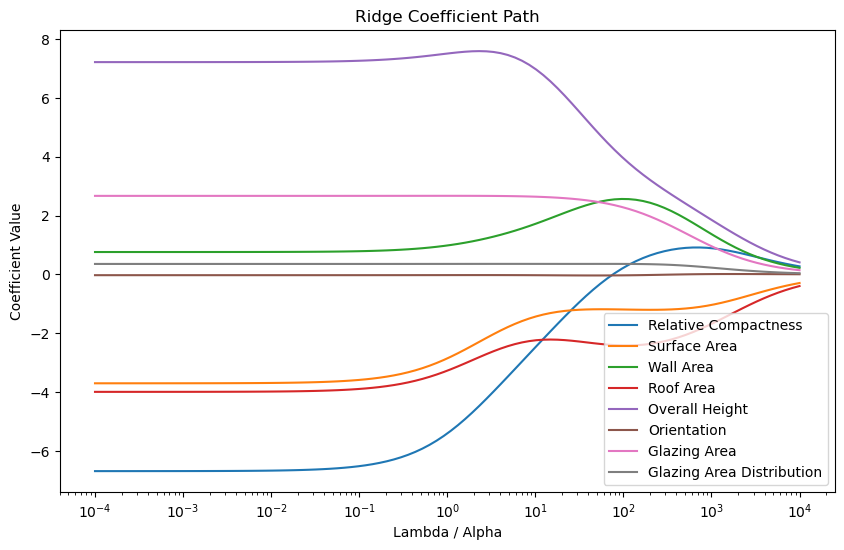

In [40]:
# Ridge coefficient path
ridge_coefs = []

# Loop through lambda value by creating a Ridge model (w/ current lambda value)
# Fit the ridge model on scaled training data and store the coefficient
for alpha in lambdas:
    ridge = Ridge(alpha = alpha)
    ridge.fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge.coef_)
    
# Convert the list into `NumPy` array for easier plotting
ridge_coefs = np.array(ridge_coefs)

plt.figure(figsize = (10, 6))

# Plot one line per predictor and show how the predictor's coef changes as lambda increases
for i, feature in enumerate(feature_names):
    plt.plot(lambdas, ridge_coefs[ :, i], label = feature)
    
# Use log scale for lambda values
plt.xscale('log')

# Add labels
plt.xlabel('Lambda / Alpha')
plt.ylabel('Coefficient Value')
plt.title('Ridge Coefficient Path')
plt.legend()
plt.show()

> **Q2: Which 2 predictors appear to be most important in the coefficient profile above? Explain your answer.**

_Overall Height and Relative Compactness appear to be the most important predictors because they consistently have the largest coefficient magnitutes across the Ridge coefficient path. Overall Height stays strongly positive around **7**, while Relative Compactness stays strongly negative around **-6** for smaller lambda values. This suggests these variables have the strongest influence on predicting Heating Load._

<!-- END QUESTION -->

### Step 7: Fit Lasso with Cross-Validation

Now fit a `LassoCV` model using the same lambda range and 10-fold CV. Create a table comparing the coefficients for both OLS and Lasso. Your table should include the following columns: `Feature`, `OLS Coefficient`, `Lasso Coefficient`. 

In [41]:
# Fit Lasso using CV (Lasso uses L1 penalty which can shrink some cofficients to zero)
lasso_cv = LassoCV(alphas = lambdas,
                   cv = 10,
                   max_iter = 100000,
                   random_state = 42)

# Train the `LassoCV()` model on scaled training data
# Create a coefficient comparison table for OLS and Lasso which helps to identify changes
lasso_cv.fit(X_train_scaled, y_train)
lasso_coef_table = pd.DataFrame({'Feature': feature_names,
                                'OLS Coefficient': ols.coef_,
                                'Lasso Coefficient': lasso_cv.coef_})
lasso_coef_table

,Feature,OLS Coefficient,Lasso Coefficient
0,Relative Compactness,-6.686924,-6.418330
1,Surface Area,-3.701472,-6.231035
2,Wall Area,0.761142,2.152524
3,Roof Area,-3.992429,-1.044324
4,Overall Height,7.216818,7.309160
5,Orientation,-0.026067,-0.023593
6,Glazing Area,2.670032,2.670194
7,Glazing Area Distribution,0.356042,0.354971


In [42]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q3: Did lasso shrink the coefficients in the same way Ridge did? Comment on any differences.**

_Lasso did not shrink the coefficients the same way Ridge did. Ridge shrinks coefficients more smoothly and kept all predictors in the model, while Lasso changes some coeffcients more aggressively. For example, `Roof Area` changed from **-3.9924** to **-1.0443**, while some other coefficients changed very little. This shows Lasso can reduce the influence of certain predictors more strongly than Ridge._

<!-- END QUESTION -->

### Step 8: Evaluate Lasso Model

Use the cross-validated lasso model from Step 7 to predict on the test set and compute MSE.

In [43]:
# Predict Heating Load on test set
y_test_pred_lcv = lasso_cv.predict(X_test_scaled)

# Calculate Lasso test MSE
mse_lcv = mean_squared_error(y_test, y_test_pred_lcv)
mse_lcv

8.841570854996332

In [44]:
# Compare the test MSE values
mse_table = pd.DataFrame({'Model': ['OLS', 'Ridge CV', 'Lasso CV'],
                          'Test MSE': [mse_ols, mse_rcv, mse_lcv]})
mse_table

,Model,Test MSE
0,OLS,8.839503
1,Ridge CV,8.843961
2,Lasso CV,8.841571


In [45]:
grader.check("q6")

q6 results: All test cases passed!

<!-- BEGIN QUESTION -->

### Step 9: Compare Ridge and Lasso

Now that both models are fitted and evaluated, create the following: 
- A table comparing the Test MSE for OLS, Ridge CV, and Lasso CV.
- A singular plot to show how MSE responds to regularization strength across all alphas (for both lasso CV and ridge CV)
- A bar plot showing how coefficient estimates differ for OLS, Lasso CV, and Ridge CV

Write 1 -2 sentences explaining the results for each plot.


*Hint: Refer back to Lab 5 for help with code on both these plots!*

In [ ]:
# Create a table of coefficients for all three models 
# Rows are features and columns are model coef estimates
coef_comparison = pd.DataFrame({'Feature': feature_names,
                                'OLS': ols.coef_,
                                'Ridge CV': ridge_cv.coef_,
                                'Lasso Coefficient': lasso_cv.coef_})

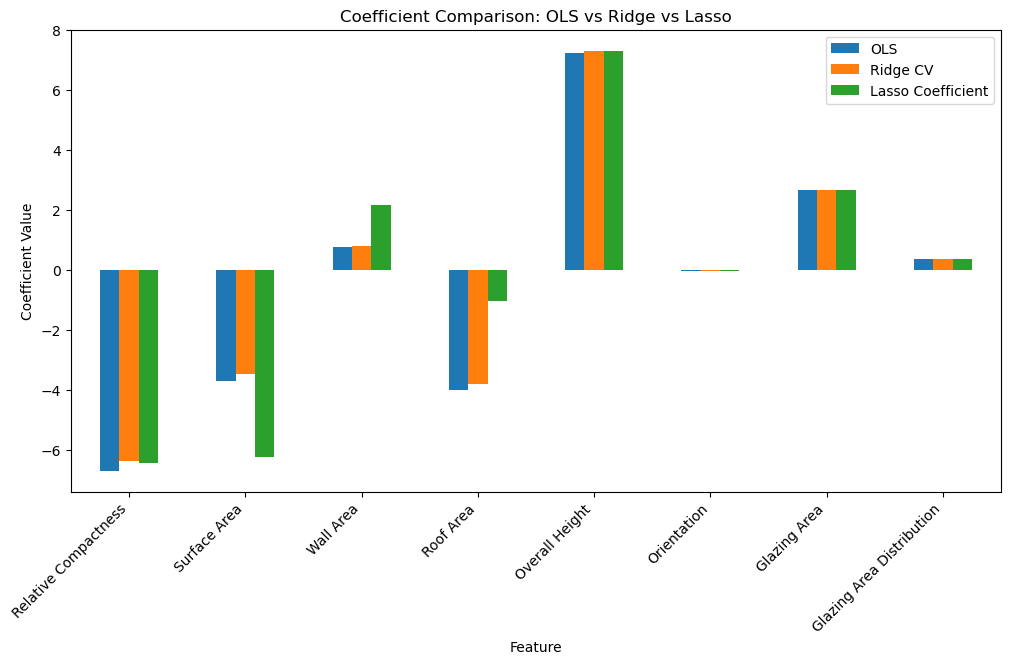

In [ ]:
# Set Feature as the index which will make feature names to appear on x-axis
# Plot bar graph to compare coefficients
coef_comparison.set_index('Feature').plot(kind = 'bar', figsize = (12, 6))

# Add labels
plt.ylabel('Coefficient Value')
plt.title('Coefficient Comparison: OLS vs Ridge vs Lasso')
plt.xticks(rotation = 45, ha = 'right') # Rotate so that it's easier to read
plt.show()

> **Q4: Which model would you pick for this dataset? Why?**

_I would pick Ridge, but Lasso is also reasonable. Ridge keeps the coefficients more balanced and stable across predictors, while Lasso changes some coefficients more aggressively, such as Surface Area and Wall Area. Since all predictors are important, Ridge is likely the safer choice for preserving information while reducing overfitting._

<!-- END QUESTION -->

---

## Part 2: Principal Components Regression (PCR)

### Background

**Principal Component Analysis (PCA)** is a dimensionality-reduction technique whose goal is to *capture as much about the data as possible in as few dimensions as possible*. It does this by finding a new set of axes — the **principal components (PCs)** — where:

- **PC1** points in the direction of **maximum variance** in the data.
- **PC2** is orthogonal to PC1 and points in the next direction of greatest remaining variance.
- Each subsequent component is orthogonal to all previous ones and explains less variance.

Each observation gets a new coordinate in this rotated space called a **score**. The contribution of each original feature to a PC is called a **loading**.

The **Proportion of Variance Explained (PVE)** measures each component's share of total variance. A common rule of thumb is to keep enough components to explain **90–95% of the total variance**.

---

**Principal Components Regression (PCR)** connects unsupervised PCA structure to a supervised response:

1. **Standardize** the predictors.
2. **Compute** the principal components.
3. **Project** the observations onto *M* components (the scores).
4. **Fit OLS** on the projected data (the *M* scores) rather than the original features.

The key assumption is that *"directions in which the predictors show the most variation are often also the directions most strongly associated with the response."* By discarding low-variance components we reduce noise, not signal.

---

**How PCR differs from Ridge and Lasso:**

| | Ridge | Lasso | PCR |
|---|---|---|---|
| Mechanism | L2 penalty shrinks all coefs | L1 penalty can zero out coefs | Drops low-variance directions |
| Variable selection? | No | Yes (exact zeros) | No — uses linear combinations of *all* predictors |
| Tuning parameter | λ (penalty strength) | λ (penalty strength) | *M* (number of components) |

Unlike Lasso, **PCR cannot perform variable selection** — every original feature still contributes to each PC. Lasso tends to outperform PCR when truly irrelevant predictors exist, because it can set those coefficients exactly to zero.

### Step 10: Fit PCA and Inspect Explained Variance

In the cells below:
1. Fit a `PCA` object on `X_train_scaled` using all 8 components.
2. Store the explained variances in a variable called `explained_var` and the cumulative variance in a variable called `cumulative_var`. Print a table showing each component's individual and cumulative explained variance (%).
3. Create a plot with:
   - A **bar chart** showing the individual explained variance (%) for each component.
   - A **line plot** overlaid showing the cumulative explained variance (%).

Use the plot to identify where cumulative variance first reaches ~90% and where the "elbow" in the bar chart occurs. You'll use this to choose *k* in the next step.

After fitting a `PCA` object, two attributes give you the variance information you need:

```python
pca.explained_variance_ratio_      # Array of length n_components
                                   # Each value = fraction of total variance explained by that PC
                                   # E.g. [0.45, 0.30, ...] means PC1 explains 45%, PC2 explains 30%

np.cumsum(pca.explained_variance_ratio_)   # Cumulative variance total used for finding the "elbow" and checking how many components hit the 90% threshold
                                           
```

In [ ]:
# Fit PCA using all 8 components on the scaled training data
pca_full = PCA(n_components = 8)
pca_full.fit(X_train_scaled)

# Use the proportion of total predictor which explained by each PCs
# Check how much total variance is explained as we add more components
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

In [ ]:
# Create a table of PCA variance results
pca_table = pd.DataFrame({'Principal Component': np.arange(1, 9),
                          'Explained Variance (%)': explained_var * 100,
                          'Cumulative Variance (%)': cumulative_var * 100})
pca_table

,Principal Component,Explained Variance (%),Cumulative Variance (%)
0,1,4.629048e+01,46.290475
1,2,1.563182e+01,61.922293
2,3,1.497484e+01,76.897136
3,4,1.243148e+01,89.328613
4,5,9.966322e+00,99.294935
5,6,6.477268e-01,99.942662
6,7,5.733790e-02,100.000000
7,8,1.097974e-30,100.000000


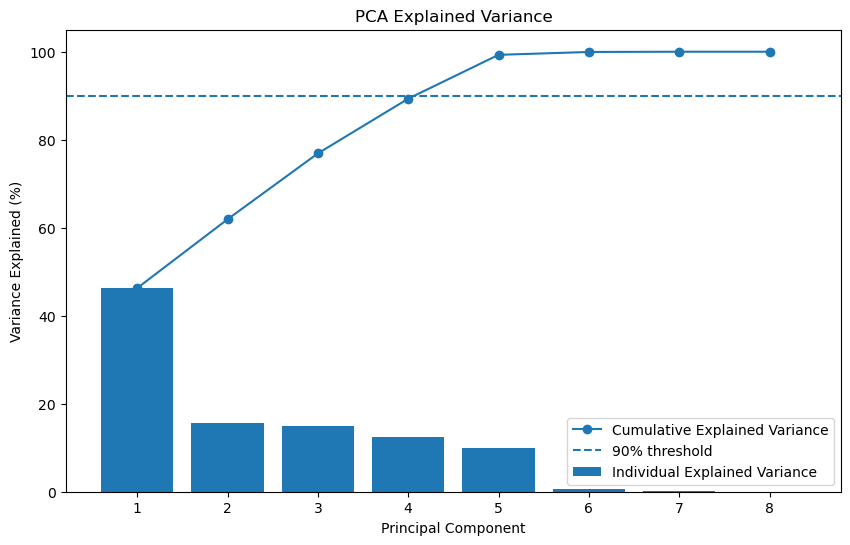

In [ ]:
# PCA individual and cumulative explained variance plot
plt.figure(figsize = (10, 6))

# Bar plot shows how much variance each individual PC explains
plt.bar(np.arange(1, 9), 
        explained_var * 100, 
        label = 'Individual Explained Variance')

# Line plot shows cumulative variance explained as components are added
plt.plot(np.arange(1, 9), 
        cumulative_var * 100, marker = 'o',
        label = 'Cumulative Explained Variance')

# Add horizontal line at 90% to help identify how many PCs needed to explain 90%+ variance
plt.axhline(y = 90, linestyle = '--', label = '90% threshold')

# Add labels
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.title('PCA Explained Variance')
plt.legend()
plt.show()

In [51]:
grader.check("q7")

q7 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q5: How many principal components does it take to explain at least 90% of the variance in the features?**

_It takes **5 principal components** to explain at least **90% of the variance**. The first 4 componeents explain about **89.33%** of the variance (just below the 90% threshold), while the first 5 components explain about **99.29%**. The largest amount of variance is captured by PC1 alone at **46.29%**, and the additional components contribute smalleer amounts afterward._

<!-- END QUESTION -->

### Step 11: Fit the Final PCR Model

PCR follows four concrete steps:

1. **Standardize the predictors** (mean 0, SD 1) (done in Step 2 with `StandardScaler`)
2. **Compute the principal components** of the standardized predictors (done in Step 10 with `PCA`)
3. **Project each observation onto the first *k* components** ( `pca_final.transform()` gives you the scores)
4. **Fit OLS of y on this new projected data** (`LinearRegression` on the PC scores)

You have already done steps 1 and 2. Now, set `best_k` based on the "elbow" or ~90% cumulative variance threshold from your plot above. Then carry out steps 3 and 4 by initializing `PCA(n_components = best_k`), transforming with `X_train_scaled` and `X_test_scaled`, and then fitting a `LinearRegression` with this transformed data. 

In [52]:
# Set k knowing elbow or ~90% cumulative variance threshold (check plot)
best_k = 5

pca_final = PCA(n_components = best_k)

# Fit PCA on training data and transform train & test data
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca  = pca_final.transform(X_test_scaled)

# Fit OLS using PC scores
ols_pcr = LinearRegression()
ols_pcr.fit(X_train_pca, y_train)

# Predict and evaluate
y_pred_pcr = ols_pcr.predict(X_test_pca)
mse_pcr = mean_squared_error(y_test, y_pred_pcr)
mse_pcr

12.703309519458253

<!-- BEGIN QUESTION -->

> **Q6: What value of k did you pick? Why?**

_I picked k = 5 becausse the first 5 principle components explain about 99.29% of the total variance, which passes 90% threshold. Using only 4 components explained about 89.33%, so 5 components captured almost all of the information in the predictors in few dimension as possible._

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

---

## Final Comparison: OLS, Ridge, Lasso, and PCR

Now that all four models have been fitted and evaluated, bring the results together.

### Step 12: Summary Table

Build a summary table comparing the test MSE across all four models. Your table should have three columns: `Model`, `Tuning Parameter` (specify the lambda/ number of components chosen), and `Test MSE`. 

In [ ]:
# Final summary table for all four models
# Tuning Pararmeter for selected lambda of Ridge and Lasso
summary_table = pd.DataFrame({'Model': ['OLS', 'Ridge CV', 'Lasso CV', 'PCR'],
                              'Turning Parameter': ['None',
                                                    ridge_cv.alpha_,
                                                    lasso_cv.alpha_,
                                                    best_k],
                              'Test MSE': [mse_ols, mse_rcv, mse_lcv, mse_pcr]})
summary_table

,Model,Turning Parameter,Test MSE
0,OLS,None,8.839503
1,Ridge CV,0.205651,8.843961
2,Lasso CV,0.00163,8.841571
3,PCR,5,12.703310


For PCR to perform well a key assumption must hold: the directions that show the most variation in the predictors are also the directions most strongly associated with the response. Lasso and ridge aim to shrink the coefficients associated with predictors wit little predictive value.

> **Q7: Comment on the results in the table above. Which model performs best? Are the differences meaningful, or do the models perform similarly? What might explain the pattern you see?**

_OLS performed best with the lowest test MSE (**8.839503**), while Ridge (**8.8439961**) and Lasso (**8.8416**) performed almost the same. This mmeans the differences between those models are very small. PCR performed worse with an MSE of **12.7033**. This suggests most predictors were already useful, so regularization and dimensionality reduction did not improve performance much. The original variables already did a good job predicting `Heating Load`, so shrinking the coefficients or combining variables into principal components did not help much. PCR likely lost some useful information when reducing the data down to only **5 components**._ 

<!-- END QUESTION -->



---

Run the cell below to receive credit for the augotraded questions. 

In [54]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!

q6 results: All test cases passed!

q7 results: All test cases passed!